In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 1. Загрузка данных
customer = pd.read_csv('customer.csv')
payment = pd.read_csv('payment.csv')

# 2. Агрегация данных для графиков
merged = customer.merge(payment, on='customer_id')
stats = merged.groupby(['customer_id', 'first_name', 'last_name', 'store_id']).agg(
    total_rentals=('rental_id', 'nunique'),
    total_spent=('amount', 'sum')
).reset_index()
stats['full_name'] = stats['first_name'] + ' ' + stats['last_name']

# 3. Категоризация для тепловой карты (Статусы клиентов)
conditions = [stats['total_spent'] > 150, stats['total_spent'] > 100]
choices = ['VIP', 'Premium']
stats['status'] = np.select(conditions, choices, default='Standard')

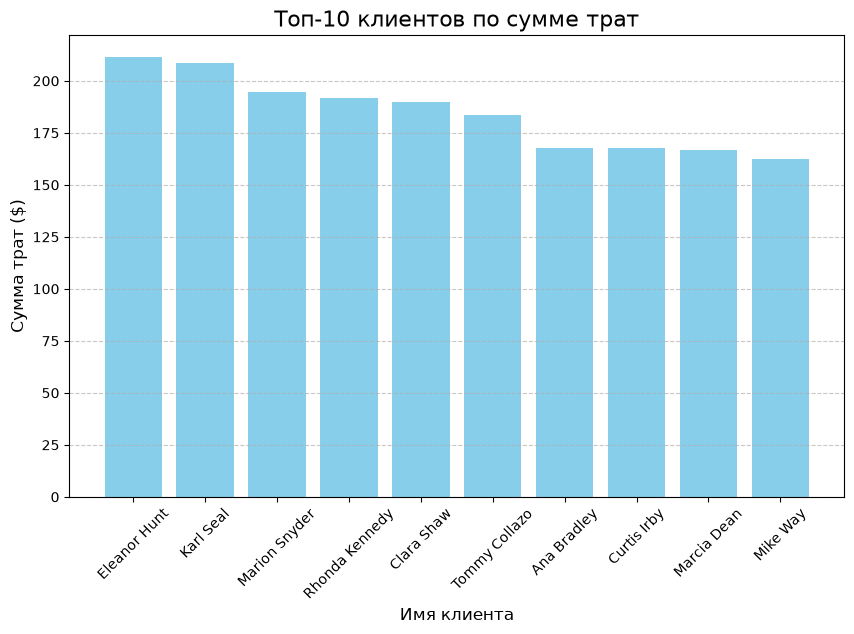

In [4]:
# Выбираем топ-10
top_10 = stats.sort_values('total_spent', ascending=False).head(10)

plt.figure(figsize=(10, 6)) # Изменение размеров графика
plt.bar(top_10['full_name'], top_10['total_spent'], color='skyblue') # Столбчатая диаграмма
plt.title('Топ-10 клиентов по сумме трат', fontsize=16) # Добавление заголовка
plt.xlabel('Имя клиента', fontsize=12) # Подписи к осям[cite: 5]
plt.ylabel('Сумма трат ($)', fontsize=12) 
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Добавление сетки[cite: 5]
plt.show() # Отображение графика[cite: 5]

Топ однороден: ни одного «кита», который бы кратно отрывался от остальных. Спуск от первого к десятому месту плавный. Значит, единая VIP-программа сработает на всю группу — точечные условия под конкретного клиента не нужны.

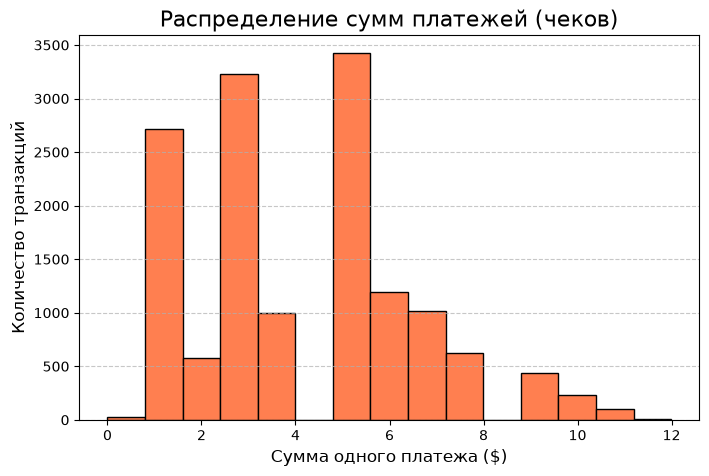

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(payment['amount'], bins=15, color='coral', edgecolor='black') # Гистограмма
plt.title('Распределение сумм платежей (чеков)', fontsize=16)
plt.xlabel('Сумма одного платежа ($)', fontsize=12)
plt.ylabel('Количество транзакций', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Три чётких пика вместо плавной кривой — платежи привязаны к фиксированным тарифам, а не к свободному ценообразованию. Спрос предсказуем и управляется тарифной политикой, а не поведением клиента.

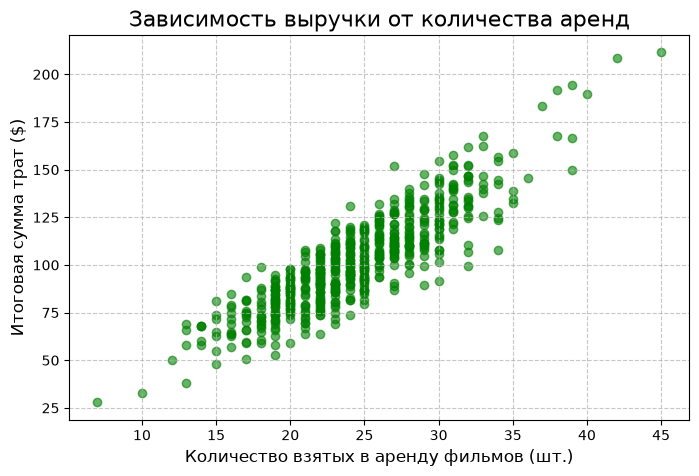

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(stats['total_rentals'], stats['total_spent'], alpha=0.6, color='green') # Точечный график
plt.title('Зависимость выручки от количества аренд', fontsize=16)
plt.xlabel('Количество взятых в аренду фильмов (шт.)', fontsize=12)
plt.ylabel('Итоговая сумма трат ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Точки идут плотным шнуром вдоль одной линии, без разрывов и выбросов. Трата — прямое и надёжное следствие количества аренд: маркетингу не нужно искать скрытые сегменты, достаточно стимулировать частоту.

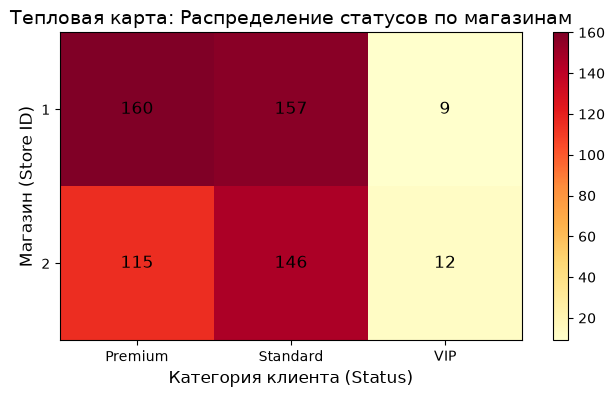

In [7]:
# Создаем сводную таблицу (Store ID х Status)
pivot_data = stats.pivot_table(index='store_id', columns='status', values='customer_id', aggfunc='count')

fig, ax = plt.subplots(figsize=(8, 4))
cax = ax.imshow(pivot_data.values, cmap='YlOrRd')

# В Matplotlib значения на тепловую карту добавляются вручную через цикл
for i in range(pivot_data.shape[0]):
    for j in range(pivot_data.shape[1]):
        ax.text(j, i, int(pivot_data.values[i, j]), ha="center", va="center", color="black", fontsize=12)

# Настройка подписей
ax.set_xticks(np.arange(len(pivot_data.columns)))
ax.set_yticks(np.arange(len(pivot_data.index)))
ax.set_xticklabels(pivot_data.columns)
ax.set_yticklabels(pivot_data.index)

plt.title('Тепловая карта: Распределение статусов по магазинам', fontsize=14)
plt.xlabel('Категория клиента (Status)', fontsize=12)
plt.ylabel('Магазин (Store ID)', fontsize=12)
fig.colorbar(cax) # Шкала цветов
plt.show()

Тепловая карта распределения статусов по магазинам позволяет быстро выявить структурные аномалии. Визуально матрица показывает, что Магазин №1 крупнее по числу массовых клиентов (Standard и Premium). Однако в VIP-сегменте (траты от $150) лидирует Магазин №2 — там таких клиентов больше (12 против 9). Этот инсайт говорит о том, что вторая точка эффективнее работает с высокодоходной аудиторией. Бизнесу стоит изучить причину этого успеха (возможно, более удачная локация или навыки персонала делать допродажи) и масштабировать этот опыт на первый филиал.